In [178]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import warnings

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Gerät: {device}")

# Das überlegene BLIP Modell laden
model_name = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name).to(device)

model.eval()
for param in model.parameters():
    param.requires_grad = True # Gradienten aktivieren
print("BLIP-Modell erfolgreich geladen!")

Nutze Gerät: cpu


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 44237.20it/s]


BLIP-Modell erfolgreich geladen!


In [179]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    # SICHERHEITS-CHECK: Nur entpacken, wenn es wirklich ein Tuple ist!
    activations = output[0] if isinstance(output, tuple) else output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0] if isinstance(grad_output, tuple) else grad_output

# Wir zapfen die letzte Bild-Schicht von BLIP an
target_layer = model.vision_model.encoder.layers[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)
print("Sensoren am BLIP Vision-Encoder angebracht (mit Tuple-Fix)!")

Sensoren am BLIP Vision-Encoder angebracht (mit Tuple-Fix)!


In [180]:
def generate_blip_gradcam(image_path, target_word):
    # 1. Bild verarbeiten
    original_image = Image.open(image_path).convert("RGB")
    image = original_image.resize((224, 224))
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    
    # 2. Den perfekten Satz mit BLIP generieren
    output_ids = model.generate(pixel_values, max_length=20)
    generated_text = processor.decode(output_ids[0], skip_special_tokens=True)
    print(f"\nGenerierter Satz: '{generated_text}'")
    
    # 3. Das gewünschte Token im Satz finden
    word_index = -1
    target_token_id = -1
    current_string = ""
    
    for i, token_id in enumerate(output_ids[0]):
        token_str = processor.decode([token_id])
        current_string += token_str
        if target_word.lower() in current_string.lower():
            word_index = i
            target_token_id = token_id
            print(f"-> Treffer! '{target_word}' vervollständigt durch Token '{token_str}' an Position {i}")
            break
            
    if word_index <= 0:
        print(f"ABBRUCH: Das Wort '{target_word}' konnte im Satz nicht zugeordnet werden.")
        return image, None, generated_text
        
    # 4. Den Logit-Score abgreifen (-1 Trick für kausale Decoder)
    model.zero_grad()
    outputs = model(pixel_values=pixel_values, input_ids=output_ids)
    target_score = outputs.logits[0, word_index - 1, target_token_id]
    
    # 5. Rückwärtsweg (Gradienten fließen durch das Netz)
    target_score.backward(retain_graph=True)
    
    # 6. Grad-CAM Mathematik
    global activations, gradients
    act = activations[0, 1:, :] 
    grad = gradients[0, 1:, :]  
    
    grid_size = int(np.sqrt(act.shape[0]))
    act = act.reshape(grid_size, grid_size, -1).permute(2, 0, 1)   
    grad = grad.reshape(grid_size, grid_size, -1).permute(2, 0, 1) 
    
    pooled_gradients = torch.mean(grad, dim=[1, 2]) 
    for i in range(act.shape[0]):
        act[i, :, :] *= pooled_gradients[i]
        
    heatmap = torch.sum(act, dim=0).squeeze().detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0) # Alle negativen Werte unterdrücken
    
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)
    
    return image, heatmap, generated_text


Generierter Satz: 'a soccer ball on the field of a stadium'
-> Treffer! 'stadium' vervollständigt durch Token 'stadium' an Position 9


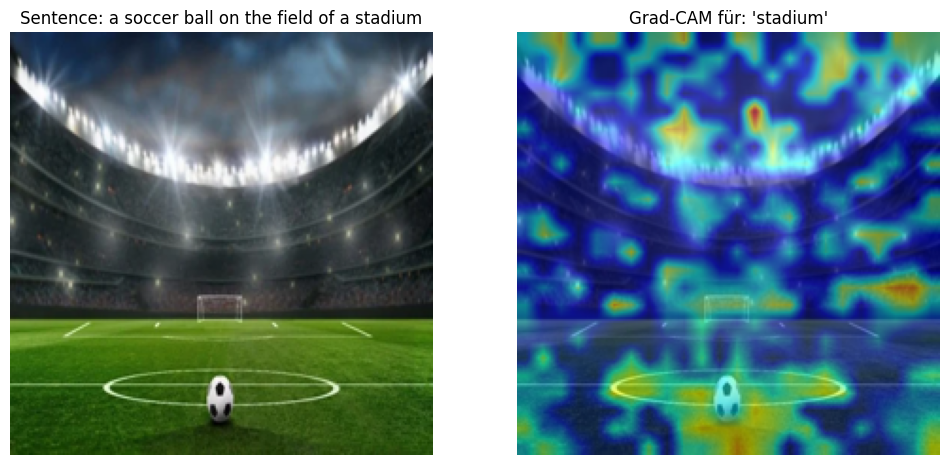

In [181]:
# HIER DEIN EIGENES BILD LADEN
image_path = "test_images/football.png" 
target_word = "stadium" # Trage hier ein Wort aus dem generierten Satz ein!

img_pil, heatmap, text = generate_blip_gradcam(image_path, target_word)

if heatmap is not None:
    img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    
    heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
    # Wir machen die harten Pixelkanten weich, damit es aussieht wie im Paper
    #heatmap_resized = cv2.GaussianBlur(heatmap_resized, (21, 21), 0) 
    
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed_img = heatmap_color * 0.5 + img_cv * 0.5
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Anzeigen
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_pil)
    plt.title(f"Sentence: {text}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM für: '{target_word}'")
    plt.axis('off')
    plt.show()